# Objective
The objective of this analysis is to evaluate product performance across key business dimensions: sales contribution, profitability, demand efficiency, and capital allocation in order to:

- Identify top performing products driving revenue and overall business performance
- Analyze pack size wise performance to understand demand and profitability patterns
- Assess contribution across revenue, procurement, and profit using sales volume based brand segmentation
- Identify high potential products for scaling based on margin strength and sell-through performance
- Optimize procurement allocation by aligning investment with margin, demand, and capital efficiency

This enables data-driven decision making for portfolio optimization, demand-driven scaling, and efficient capital allocation, ultimately improving overall business performance and profitability.

### Importing libraries

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sqlalchemy import create_engine,text
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

### Connection setup and Reading required datasets

In [2]:
# load env file and import credentials
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_HOST = os.getenv("DB_HOST")
DB_PASSWORD = os.getenv("DB_PASSWORD")

# establish connection to the 'inventory_db' database
conn_url = URL.create (
    drivername = "mysql+pymysql",
    host = DB_HOST,
    username = DB_USER,
    password = DB_PASSWORD,
    database = 'inventory_db'
)
conn_eng = create_engine(conn_url)
print("Connection Open to 'inventory_db' database")

Connection Open to 'inventory_db' database


In [3]:
# reading required datasets from the database
with conn_eng.connect() as conn:
    dataset   = pd.read_sql(text("select * from product_summary;"), conn)
    begin_inv = pd.read_sql(text('''select ProductId,sum(onHand) as BeginningInv
                                    from begin_inventory
                                    group by ProductId'''),conn)

print("(Rows, Columns) :",dataset.shape)
dataset.head(3)

(Rows, Columns) : (10485, 14)


,ProductId,Description,VendorNumber,VendorName,Volume_ml,ActualPrice,PurchasePrice,TotalQuantityPurchased,TotalPurchaseDollars,SalesPrice,TotalQuantitySold,TotalSalesDollars,GrossProfit,GrossProfitMargin
0,58,Gekkeikan Black & Gold Sake,8320,SHAW ROSS INT L IMP LTD,750,12.99,9.28,3550,32944.0,12.58,3446,43341.54,11362.66,26.22
1,62,Herradura Silver Tequila,1128,BROWN-FORMAN CORP,750,36.99,28.67,3200,91744.0,38.36,3125,119863.75,30270.00,25.25
2,63,Herradura Reposado Tequila,1128,BROWN-FORMAN CORP,750,38.99,30.46,2855,86963.3,40.41,2778,112249.22,27631.34,24.62


In [4]:
# Data enrichment
dataset = dataset.merge(begin_inv, on='ProductId', how='left')

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10485 entries, 0 to 10484
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ProductId               10485 non-null  int64  
 1   Description             10485 non-null  object 
 2   VendorNumber            10485 non-null  int64  
 3   VendorName              10485 non-null  object 
 4   Volume_ml               10485 non-null  int64  
 5   ActualPrice             10485 non-null  float64
 6   PurchasePrice           10485 non-null  float64
 7   TotalQuantityPurchased  10485 non-null  int64  
 8   TotalPurchaseDollars    10485 non-null  float64
 9   SalesPrice              10485 non-null  float64
 10  TotalQuantitySold       10485 non-null  int64  
 11  TotalSalesDollars       10485 non-null  float64
 12  GrossProfit             10485 non-null  float64
 13  GrossProfitMargin       10485 non-null  float64
 14  BeginningInv            7272 non-null 

### Data Preparation

In [5]:
# Preparing summary dataset for analysis
product_summary = dataset.groupby(['Description','Volume_ml']).agg({
    'PurchasePrice' : 'mean',
    'SalesPrice' : 'mean',
    'TotalQuantityPurchased' : 'sum',
    'TotalQuantitySold' : 'sum',
    'TotalPurchaseDollars' : 'sum',
    'TotalSalesDollars' : 'sum',
    'GrossProfit' : 'sum',
    'BeginningInv' : 'sum'
}).reset_index()
product_summary.head(3)

,Description,Volume_ml,PurchasePrice,SalesPrice,TotalQuantityPurchased,TotalQuantitySold,TotalPurchaseDollars,TotalSalesDollars,GrossProfit,BeginningInv
0,(RI) 1,750,26.92,36.41,655,591,17632.60,21519.09,5609.37,225.0
1,.nparalleled Svgn Blanc,750,5.36,7.99,143,137,766.48,1094.63,360.31,0.0
2,10 Span Cab Svgn CC,750,4.96,7.49,431,361,2137.76,2703.89,913.33,0.0


In [6]:
# Calculated Columns for better analysis

# Gross Profit Margin = Gross Profit*100/ Revenue
product_summary['GrossProfitMargin']=(product_summary['GrossProfit']*100/
                                      product_summary['TotalSalesDollars']).round(2)

# Sell Through Ratio = Qty Sold/ Available Qty
product_summary['SellThroughRatio']=(product_summary['TotalQuantitySold']/
                                    (product_summary['TotalQuantityPurchased'] +
                                     product_summary['BeginningInv'])).round(2)

# Revenue, Purchase and Profit Share
product_summary['SalesContribution'] = (product_summary['TotalSalesDollars']*100 /
                                      product_summary['TotalSalesDollars'].sum())

product_summary['PurchaseContribution'] = (product_summary['TotalPurchaseDollars']*100 /
                                      product_summary['TotalPurchaseDollars'].sum())

product_summary['ProfitContribution'] = (product_summary['GrossProfit']*100 /
                                      product_summary['GrossProfit'].sum())

In [7]:
# user defined function to format currency values
def format_currency(value):
    if abs(value) >= 1000_000:
        return f"${round(value/1000_000,2)}M"
    elif abs(value) >= 1000:
        return f"${round(value/1000,2)}K"
    else:
        return f"${round(value,2)}"

#### Top Performers by Sales

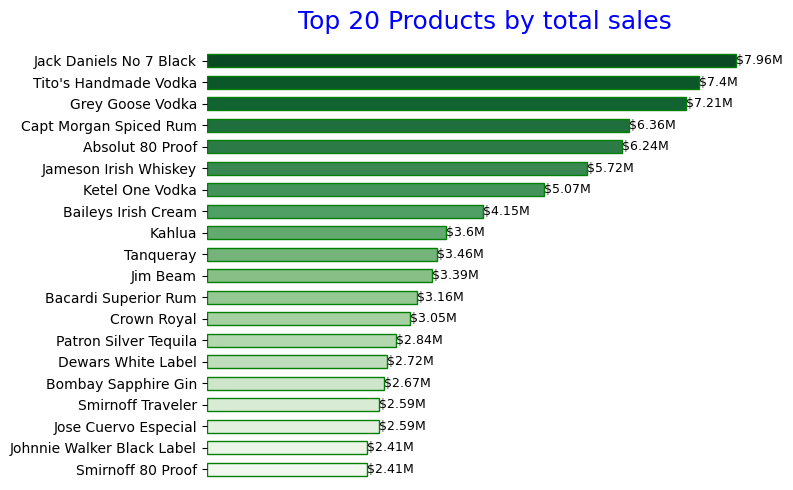

In [8]:
# top 20 products by sales 
top_sales = product_summary.groupby('Description')['TotalSalesDollars'].sum().sort_values(
                ascending=False).reset_index().head(20)

plt.figure(figsize= (8,5))

sns.barplot(data=top_sales, x='TotalSalesDollars', y='Description',width =0.6,
            hue='Description', palette='Greens_r', edgecolor='green')
for i,txt in enumerate(top_sales['TotalSalesDollars']):
    plt.text(txt,i,format_currency(txt), fontsize=9, va='center')

plt.title('Top 20 Products by total sales',color='blue', fontsize=18, pad=15)
plt.ylabel('')
plt.xlabel('')
plt.xticks([])

sns.despine(left=True,bottom=True)
plt.tight_layout()
plt.show()

#### Pack Size wise Performance

In [9]:
# Pack Size wise Segmentation
bins = [0,375,750,2000,float('inf')]
labels = ['Small','Standard','Large','Bulk']

product_summary['SizeSegment'] = pd.cut(product_summary['Volume_ml'], bins= bins, labels= labels)
product_summary['SizeSegment'].value_counts().reset_index(name = 'No_of_Products')

,SizeSegment,No_of_Products
0,Standard,8409
1,Large,1206
2,Small,684
3,Bulk,163


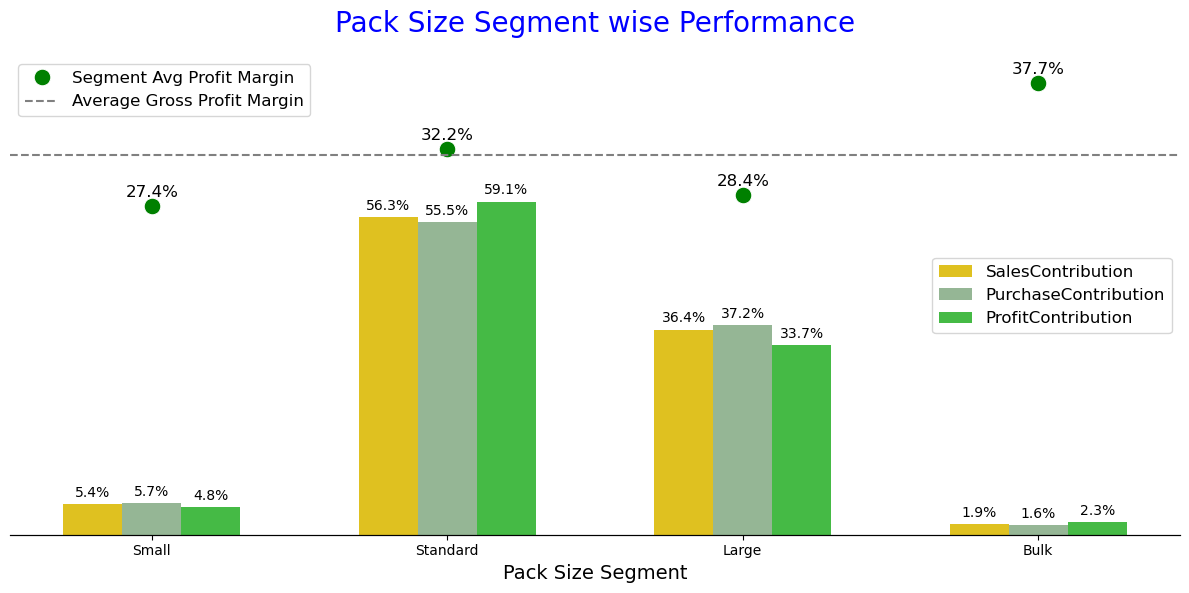

In [10]:
grouped_segment = product_summary.groupby('SizeSegment',observed=False).agg({
    'SalesContribution' : 'sum',
    'PurchaseContribution' : 'sum',
    'ProfitContribution' : 'sum'
    }).round(2).reset_index()

grouped_segment=grouped_segment.melt( id_vars='SizeSegment',
                    value_vars=['SalesContribution','PurchaseContribution',
                                'ProfitContribution'],
                    var_name='Metric',value_name='Contribution')

fig,ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=grouped_segment, x='SizeSegment', y='Contribution',
                  hue='Metric', palette=['gold','darkseagreen','limegreen'], width=0.6 ,ax=ax1)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', padding=3)

ax1.set_xlabel('Pack Size Segment', fontsize=14)
ax1.set_ylabel('')
ax1.legend(loc= 'center right', fontsize=12)
ax1.set_yticks([])
ax1.set_ylim(0,85)

ax2=ax1.twinx()
df_plot = product_summary.groupby('SizeSegment', observed=False).apply(
            lambda x: x['GrossProfit'].sum()*100 / x['TotalSalesDollars'].sum(), include_groups=False
            ).reset_index(name='GrossProfitMargin')
sns.lineplot(data=df_plot, x='SizeSegment', y='GrossProfitMargin', color='lightgreen',
             label= 'Segment Avg Profit Margin',marker='o',  markersize=12 , markerfacecolor= 'green', 
             linestyle = 'None', ax=ax2)
for i,txt in enumerate(df_plot['GrossProfitMargin']):
    ax2.text(i, txt+0.5, f'{round(txt,1)}%', ha='center', va='bottom', fontsize=12)
    
ax2.axhline(product_summary['GrossProfitMargin'].mean(), label= 'Average Gross Profit Margin' ,
            linestyle= '--' , color='gray')

ax2.set_ylabel('')
ax2.set_yticks([])
ax2.set_xlabel('Pack Size Segment', fontsize=12)
ax2.set_ylim(0,40)
ax2.legend(fontsize =12 ,loc='upper left')

plt.suptitle('Pack Size Segment wise Performance', color='blue', fontsize=20)
sns.despine(left=True)
plt.tight_layout()
plt.show()

> - Standard size dominates the business with core revenue and profit, requires highest focus on availability and pricing.  

> - Large size drives volume but slightly lower margin and can be targeted for scaling and margin improvement opportunity by cost or discount optimization.  


> - Bulk size is highly profitable but under utilized indicating a strong opportunity to scale through wholesale channels.  
> - Small size has low impact despite decent margins ,indicating that they are not scaling effectively.  

> - Overall business impact is skewed towards mid sized packs (standard + large) ,but growth can come from expanding high margin bulk segment and optimizing small segment.

#### Contribution analysis (Revenue, Procurement, Profit) by Sales Volume based product buckets

In [11]:
product_contri = product_summary.groupby('Description', observed=False).agg({
                    'TotalQuantitySold' : 'sum',
                    'SalesContribution' : 'sum',
                    'PurchaseContribution' : 'sum',
                    'ProfitContribution' : 'sum'
                })
product_contri = product_contri.sort_values(by='TotalQuantitySold', ascending=False).reset_index()

product_contri['SalesContributionCum'] = product_contri['SalesContribution'].cumsum()
product_contri['PercRank'] = (product_contri.index+1)*100/len(product_contri)

# Product bucket based on sales volume
bins= [0,5,10,20,50,100]
labels = ['Top 5%','5-10%','10-20%','20-50%','Bottom 50%']

product_contri['ProductBucket'] = pd.cut(product_contri['PercRank'], bins=bins, labels=labels)

# Contribution per bucket table
contri_table = product_contri.groupby('ProductBucket', observed=False).agg(
                    No_of_Product = ('Description' , 'count'),
                    Revenue_Share = ('SalesContribution' , 'sum'),
                    Procurement_Share = ('PurchaseContribution' , 'sum'),
                    Profit_Share = ('ProfitContribution' , 'sum')
                ).round(2)

contri_table = contri_table.style.format({'Revenue_Share': '{:.2f}%','Procurement_Share': '{:.2f}%',
                'Profit_Share': '{:.2f}%'})
contri_table

,No_of_Product,Revenue_Share,Procurement_Share,Profit_Share
ProductBucket,,,,
Top 5%,474,59.54%,59.59%,58.27%
5-10%,474,13.48%,13.12%,14.18%
10-20%,948,12.75%,12.43%,13.27%
20-50%,2845,12.21%,12.41%,12.21%
Bottom 50%,4742,2.02%,2.45%,2.07%


> - The product portfolio is highly concentrated with the top 5% of products sold contribute nearly 60% of sales, purchases, and profit, indicating strong dependence on a small set of high-performing brands.  

> - While procurement is well aligned with demand overall, the bottom 50% of products contribute less to sales despite slightly higher purchase share, highlighting inefficiencies and potential dead stock.  

> - This suggests an opportunity to scale high margin products within the long tail while rationalizing low  performing products to improve overall productivity and efficiency.

#### Identify Products for scaling

- i.e. Products with high profit margin ,faster selling but low revenue 

In [12]:
high_margin = product_summary['GrossProfitMargin'].quantile(.75)
high_sellthrough = product_summary['SellThroughRatio'].quantile(0.75)
low_sales = product_summary['TotalSalesDollars'].quantile(.25)

target_brands = product_summary[(product_summary['TotalSalesDollars'] <= low_sales) &
                                (product_summary['GrossProfitMargin'] >= high_margin) &
                                (product_summary['SellThroughRatio'] >= high_sellthrough)].reset_index(drop=True)

print(f"Products with low revenue but give high profit margin and high efficiency : {len(target_brands)} products.")
display(target_brands[['Description','TotalSalesDollars','GrossProfitMargin']].round(2).head(3))

Products with low revenue but give high profit margin and high efficiency : 132 products.


,Description,TotalSalesDollars,GrossProfitMargin
0,2 Gingers Irish Whiskey,321.86,40.89
1,A by Acacia Red Cal,143.88,45.20
2,Agua de Piedra Malbec Selecn,707.16,37.99


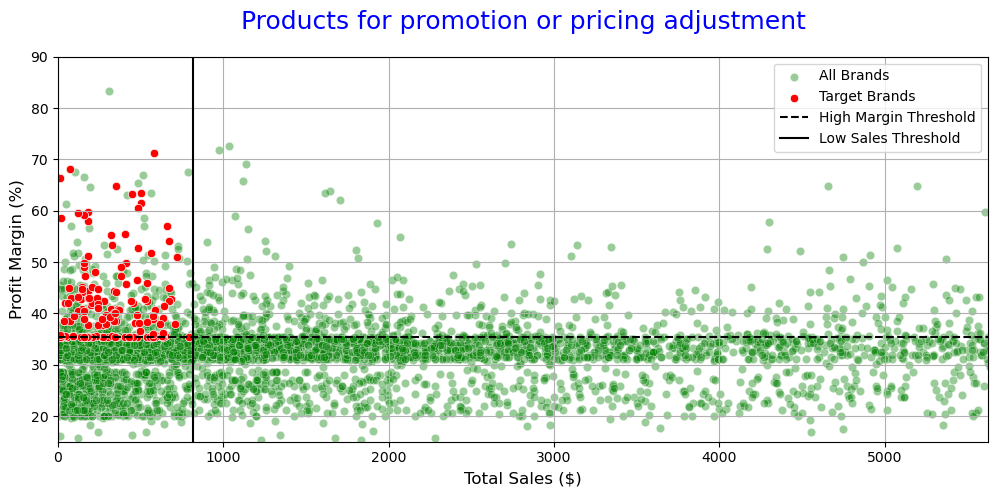

In [13]:
plt.figure(figsize=(12,5))
sns.scatterplot(data= product_summary,x='TotalSalesDollars',y='GrossProfitMargin',
                label= 'All Brands',color='green',alpha=0.4)
sns.scatterplot(data= target_brands, x='TotalSalesDollars',y='GrossProfitMargin',
                label= 'Target Brands',color='red')

plt.axhline(y=high_margin, color='black', linestyle='--', label='High Margin Threshold')
plt.axvline(x=low_sales, color='black', linestyle='-', label='Low Sales Threshold')

plt.xlim(0,product_summary['TotalSalesDollars'].median())
plt.ylim(15,90)
plt.grid(True)
plt.legend()
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Profit Margin (%)', fontsize=12)
plt.title('Products for promotion or pricing adjustment',color='blue',fontsize = 18, pad=20)
plt.show()

#### Procurement Budget Allocation Strategy
The goal is to expand procurement distribution among products to reduce concentration risk.

Allocation Score = 0.4*(Sell Through) + 0.3*(Profit Margin) + 0.3*(Capital Efficiency)   
Segmentation : Increase (Top 20% by allocation score) , Depriortize(Bottom 30%), Maintain(Middle 50%)


In [14]:
# Function for min-max normalization
def normalized_score(data) :
    x_min = data.min()
    x_max = data.max()
    score = (data-x_min) / (x_max-x_min)
    return score

In [15]:
# Captal Efficiency = Gross Profit / Purchase Cost
product_summary['CapitalEfficiency'] = product_summary['GrossProfit']/ product_summary['TotalPurchaseDollars']

# Normalized score to remove bias
product_summary['SellThroughScore'] = normalized_score(product_summary['SellThroughRatio'])
product_summary['ProfitMarginScore'] = normalized_score(product_summary['GrossProfitMargin'])
product_summary['CapitalEffScore'] = normalized_score(product_summary['CapitalEfficiency'])

# Allocation Score
product_summary['AllocationScore'] = (0.4*product_summary['SellThroughScore']
                                    + 0.3*product_summary['ProfitMarginScore']
                                    + 0.3*product_summary['CapitalEffScore'])

product_summary[['Description','AllocationScore']].sort_values(by='AllocationScore',
                                                               ascending=False).reset_index().head(5)

,index,Description,AllocationScore
0,1112,Blue Chair Bay Coconut Rum,0.904134
1,8728,Skinnygirl Tangerine Vodka,0.863297
2,917,Beniotome Sesame Shochu,0.827361
3,8893,Soli White Blend,0.792610
4,10393,Z-52 Znfdl Lodi Old Vines,0.788537


In [16]:
# Product Segmentation based on Allocation score
product_summary['AllocationSegment'] = pd.qcut(product_summary['AllocationScore'],q=[0, 0.3, 0.8, 1.0],
                                             labels=['Deprioritize','Maintain','Increase'])

proc_alloc = product_summary.groupby('AllocationSegment',observed=False).agg(
    No_of_Products = ('Description', 'count'),
    Procurement_Share = ('PurchaseContribution', 'sum')).reset_index()

proc_alloc['Procurement_Share'] = proc_alloc['Procurement_Share'].round(2).astype(str) + '%'
proc_alloc

,AllocationSegment,No_of_Products,Procurement_Share
0,Deprioritize,3139,6.71%
1,Maintain,5230,85.21%
2,Increase,2093,8.07%


> - Around 85% of procurement budget is concentrated in the "Maintain" segment which indicates heavy reliance on mid performing products.

> - Around 8% of budget is allocated to "Increase" segment suggesting scaling opportunities and increasing procurement budget.

> - Around 7% of budget is allocated to low impact "Depriortize" segment, indicating capital leakage into low impact products.

# Key Insights

#### 1. Business is driven by standard pack size with clear scaling opportunities in bulk segment

- Standard pack size dominates revenue and profit, making it the core focus area for availability and pricing.
- Large packs contribute strong volume but operate at relatively lower margins, indicating scope for margin optimization.
- Bulk packs, though highly profitable, remain underutilized, presenting a clear opportunity for scaling, while small packs have limited business impact despite decent margins.

#### 2. Product portfolio is highly concentrated with inefficiencies in the long tail

- A small set of top performing products(top 5%) drives the majority of sales, procurement, and profit, indicating strong dependence on a limited portfolio.
- While overall procurement aligns with demand, the bottom 50% contributes disproportionately lower sales despite higher purchase share, reflecting inefficiencies and potential dead stock. This creates a clear opportunity to scale high-potential products through pricing or promotion, while rationalizing underperforming products to improve overall efficiency.

#### 3. Procurement budget is heavily concentrated in mid performing products with scope for reallocation

- A large share of procurement budget is allocated to the “Maintain” segment, indicating strong reliance on mid performing products.
- The “Increase” segment receives limited allocation despite clear scaling potential, suggesting underinvestment in high-opportunity products.
- At the same time, a notable portion of budget  is tied up in low impact “Deprioritize” products, highlighting capital inefficiency and need for reallocation.

---